In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, classification_report

In [2]:
trip_df = pd.read_csv('travel_trip_data.csv')
cost_df = pd.read_csv('cost_data.csv')
weather_df = pd.read_csv('weather_data.csv')
health_df = pd.read_csv('health_data.csv')
print(trip_df)
print(cost_df)
print(weather_df)
print(health_df)

     Trip ID             Destination Start date   End date  Duration (days)  \
0          1              London, UK   5/1/2023   5/8/2023              7.0   
1          2        Phuket, Thailand  6/15/2023  6/20/2023              5.0   
2          3         Bali, Indonesia   7/1/2023   7/8/2023              7.0   
3          4           New York, USA  8/15/2023  8/29/2023             14.0   
4          5            Tokyo, Japan  9/10/2023  9/17/2023              7.0   
..       ...                     ...        ...        ...              ...   
134      135  Rio de Janeiro, Brazil   8/1/2023  8/10/2023              9.0   
135      136       Vancouver, Canada  8/15/2023  8/21/2023              6.0   
136      137       Bangkok, Thailand   9/1/2023   9/8/2023              7.0   
137      138        Barcelona, Spain  9/15/2023  9/22/2023              7.0   
138      139   Auckland, New Zealand  10/1/2023  10/8/2023              7.0   

       Traveler name  Traveler age Traveler gender 

Trip Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 71 entries, 0 to 138
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Trip ID               71 non-null     int64         
 1   Destination           71 non-null     object        
 2   Start date            71 non-null     datetime64[ns]
 3   End date              71 non-null     datetime64[ns]
 4   Duration (days)       71 non-null     float64       
 5   Traveler name         71 non-null     object        
 6   Traveler age          71 non-null     float64       
 7   Traveler gender       71 non-null     object        
 8   Traveler nationality  71 non-null     object        
 9   Accommodation type    71 non-null     object        
 10  Accommodation cost    71 non-null     float64       
 11  Transportation type   71 non-null     object        
 12  Transportation cost   71 non-null     float64       
 13  Total Trip

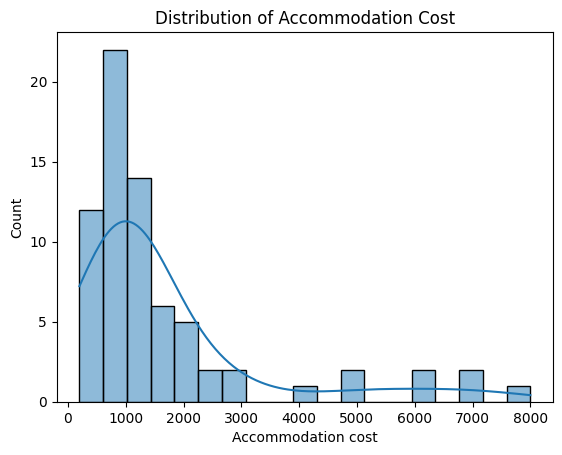

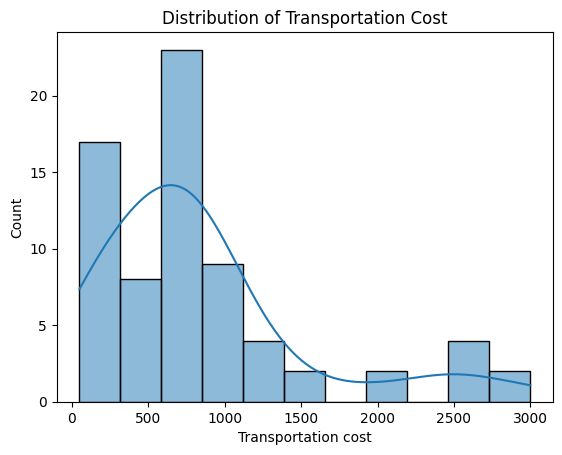

In [25]:
print("Trip Data Info:")
print(trip_df.info())
print(trip_df.describe())

print("\nCost Data Info:")
print(cost_df.info())
print(cost_df.describe())

print("\nWeather Data Info:")
print(weather_df.info())
print(weather_df.describe())

print("\nHealth Data Info:")
print(health_df.info())
print(health_df.describe())

# Display info and summary stats
print("Trip Data Info:")
trip_df.info()
print("\nTrip Data Description:")
print(trip_df.describe(include='all'))

print("\nCost Data Info:")
cost_df.info()

print("\nWeather Data Info:")
weather_df.info()

print("\nHealth Data Info:")
health_df.info()


# Visualizations for Trip Data
sns.histplot(trip_df['Accommodation cost'].dropna(), kde=True)
plt.title('Distribution of Accommodation Cost')
plt.show()

sns.histplot(trip_df['Transportation cost'].dropna(), kde=True)
plt.title('Distribution of Transportation Cost')
plt.show()

In [4]:
trip_df['Accommodation cost'] = pd.to_numeric(trip_df['Accommodation cost'], errors='coerce')
trip_df['Transportation cost'] = pd.to_numeric(trip_df['Transportation cost'], errors='coerce')
trip_df['Start date'] = pd.to_datetime(trip_df['Start date'], errors='coerce')
trip_df['End date'] = pd.to_datetime(trip_df['End date'], errors='coerce')
trip_df.dropna(subset=['Destination', 'Start date', 'End date', 'Accommodation cost', 'Transportation cost'], inplace=True)
trip_df['Total Trip Cost'] = trip_df['Accommodation cost'] + trip_df['Transportation cost']
trip_df['Country'] = trip_df['Destination'].apply(lambda x: x.split(',')[-1].strip() if isinstance(x, str) and ',' in x else np.nan)
print(trip_df)

     Trip ID             Destination Start date   End date  Duration (days)  \
0          1              London, UK 2023-05-01 2023-05-08              7.0   
1          2        Phuket, Thailand 2023-06-15 2023-06-20              5.0   
2          3         Bali, Indonesia 2023-07-01 2023-07-08              7.0   
3          4           New York, USA 2023-08-15 2023-08-29             14.0   
4          5            Tokyo, Japan 2023-09-10 2023-09-17              7.0   
..       ...                     ...        ...        ...              ...   
134      135  Rio de Janeiro, Brazil 2023-08-01 2023-08-10              9.0   
135      136       Vancouver, Canada 2023-08-15 2023-08-21              6.0   
136      137       Bangkok, Thailand 2023-09-01 2023-09-08              7.0   
137      138        Barcelona, Spain 2023-09-15 2023-09-22              7.0   
138      139   Auckland, New Zealand 2023-10-01 2023-10-08              7.0   

       Traveler name  Traveler age Traveler gender 

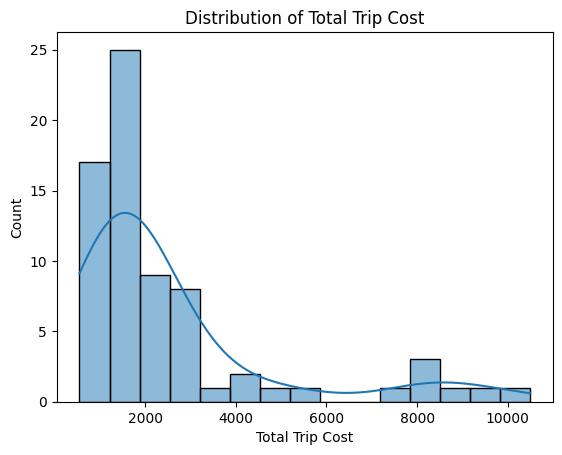

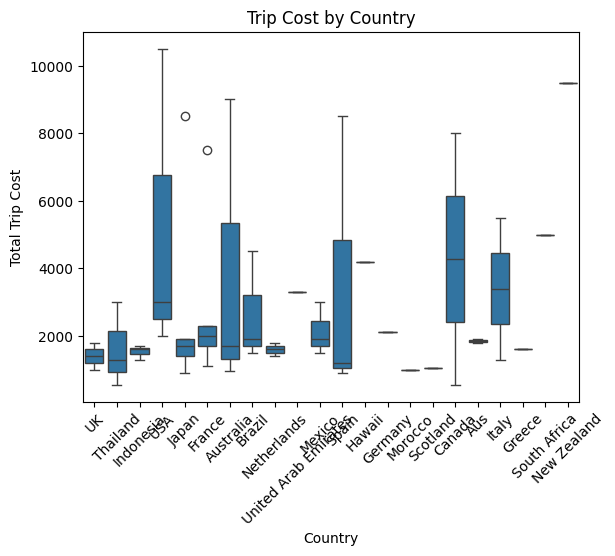

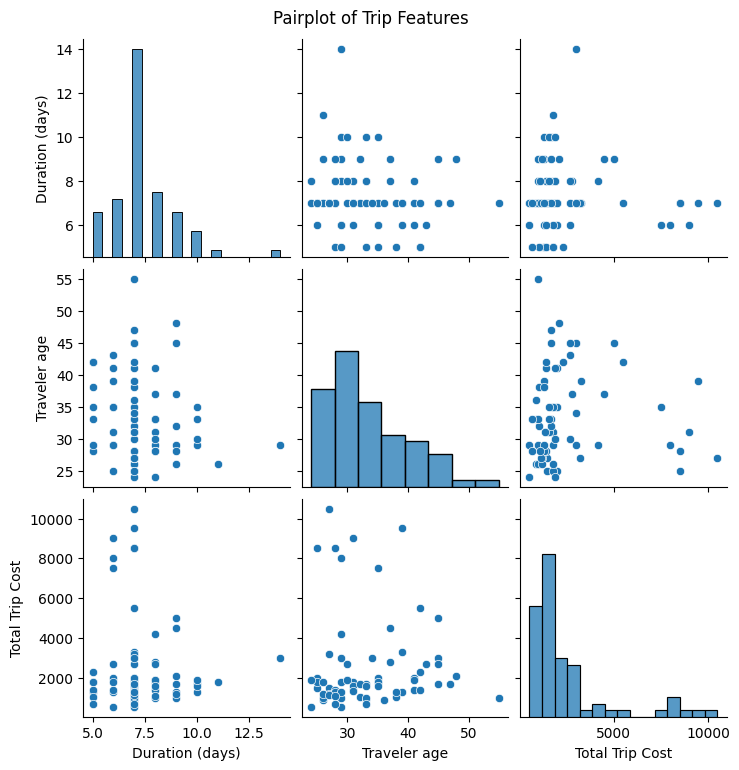

In [6]:
sns.histplot(trip_df['Total Trip Cost'].dropna(), kde=True)
plt.title('Distribution of Total Trip Cost')
plt.show()

sns.boxplot(x=trip_df['Country'], y=trip_df['Total Trip Cost'])
plt.xticks(rotation=45)
plt.title('Trip Cost by Country')
plt.show()

sns.pairplot(trip_df[['Duration (days)', 'Traveler age', 'Total Trip Cost']].dropna())
plt.suptitle('Pairplot of Trip Features', y=1.02)
plt.show()

In [9]:
weather_df_cleaned = weather_df.dropna(subset=['temperature', 'humidity', 'Country', 'City'])
weather_cost = pd.merge(weather_df_cleaned, cost_df, on='Country', how='left')
trip_merged = pd.merge(trip_df, weather_cost, on='Country', how='left')
print(trip_merged)

      Trip ID            Destination Start date   End date  Duration (days)  \
0           1             London, UK 2023-05-01 2023-05-08              7.0   
1           2       Phuket, Thailand 2023-06-15 2023-06-20              5.0   
2           3        Bali, Indonesia 2023-07-01 2023-07-08              7.0   
3           4          New York, USA 2023-08-15 2023-08-29             14.0   
4           5           Tokyo, Japan 2023-09-10 2023-09-17              7.0   
...       ...                    ...        ...        ...              ...   
3404      136      Vancouver, Canada 2023-08-15 2023-08-21              6.0   
3405      136      Vancouver, Canada 2023-08-15 2023-08-21              6.0   
3406      137      Bangkok, Thailand 2023-09-01 2023-09-08              7.0   
3407      138       Barcelona, Spain 2023-09-15 2023-09-22              7.0   
3408      139  Auckland, New Zealand 2023-10-01 2023-10-08              7.0   

        Traveler name  Traveler age Traveler gender

In [10]:
features = ['Duration (days)', 'Traveler age']
trip_cost_data = trip_merged.dropna(subset=features + ['Total Trip Cost'])
X = trip_cost_data[features]
y = trip_cost_data['Total Trip Cost']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train)
print(X_test)
print(y_train)
print(y_test)

      Duration (days)  Traveler age
2256              6.0          29.0
2171              6.0          29.0
1739              6.0          29.0
3389              6.0          29.0
1650              7.0          24.0
...               ...           ...
1095              7.0          24.0
1130              7.0          24.0
1294              7.0          24.0
860               7.0          24.0
3174              6.0          29.0

[2727 rows x 2 columns]
      Duration (days)  Traveler age
32                7.0          24.0
3398              6.0          29.0
2374              6.0          29.0
1395              7.0          24.0
229               7.0          24.0
...               ...           ...
572               7.0          24.0
1468              7.0          24.0
952               7.0          24.0
3034              6.0          29.0
2622              6.0          29.0

[682 rows x 2 columns]
2256    8000.0
2171    8000.0
1739    8000.0
3389    8000.0
1650     550.0
         ...

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Trip Cost Prediction RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Trip Cost Prediction RMSE: 1126.4440835010585


In [6]:
health_df = health_df.copy()
health_df = health_df[health_df['Cases'].apply(lambda x: isinstance(x, (int, float)) or (isinstance(x, str) and x.replace('.', '', 1).isdigit()))]
health_df['Cases'] = health_df['Cases'].astype(float)
health_df.dropna(subset=['Temp', 'preci', 'LAI', 'Cases'], inplace=True)
Xh = health_df[['Temp', 'preci', 'LAI']]
yh = health_df['Cases']

Xh_train, Xh_test, yh_train, yh_test = train_test_split(Xh, yh, test_size=0.2, random_state=42)
health_model = LinearRegression()
health_model.fit(Xh_train, yh_train)
yh_pred = health_model.predict(Xh_test)

print("Disease Case Prediction RMSE:", np.sqrt(mean_squared_error(yh_test, yh_pred)))

Disease Case Prediction RMSE: 634.2641227223374


In [16]:
trip_merged['Safe'] = trip_merged['temperature'].apply(lambda x: 1 if 15 <= x <= 30 else 0)
clf_data = trip_merged.dropna(subset=features + ['Safe'])
Xc = clf_data[features]
yc = clf_data['Safe']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42)
print(Xc_test)
print(yc_train)
print(yc_test)
print(Xc_train)

      Duration (days)  Traveler age
32                7.0          24.0
3398              6.0          29.0
2374              6.0          29.0
1395              7.0          24.0
229               7.0          24.0
...               ...           ...
572               7.0          24.0
1468              7.0          24.0
952               7.0          24.0
3034              6.0          29.0
2622              6.0          29.0

[682 rows x 2 columns]
2256    0
2171    0
1739    0
3389    0
1650    0
       ..
1095    0
1130    0
1294    0
860     0
3174    0
Name: Safe, Length: 2727, dtype: int64
32      0
3398    0
2374    0
1395    0
229     0
       ..
572     0
1468    0
952     0
3034    0
2622    0
Name: Safe, Length: 682, dtype: int64
      Duration (days)  Traveler age
2256              6.0          29.0
2171              6.0          29.0
1739              6.0          29.0
3389              6.0          29.0
1650              7.0          24.0
...               ...          

In [17]:
clf = RandomForestClassifier(random_state=42)
clf.fit(Xc_train, yc_train)
yc_pred = clf.predict(Xc_test)

print("\nTravel Suitability Classification Report:\n")
print(classification_report(yc_test, yc_pred))


Travel Suitability Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       682

    accuracy                           1.00       682
   macro avg       1.00      1.00      1.00       682
weighted avg       1.00      1.00      1.00       682



In [19]:
cluster_data = trip_merged[['temperature', 'humidity', 'Cost of Living Index']].dropna()
scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_data)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled)
cluster_data['Cluster'] = clusters
print(cluster_data)

      temperature  humidity  Cost of Living Index  Cluster
25     284.630000      76.0                  64.8        1
26     284.629041      76.0                  64.8        1
27     284.626998      76.0                  64.8        1
28     284.624955      77.0                  64.8        1
29     284.622911      78.0                  64.8        1
...           ...       ...                   ...      ...
3401   276.130000      93.0                  64.8        0
3402   276.380000      93.0                  64.8        0
3403   276.310000     100.0                  64.8        0
3404   276.170000      93.0                  64.8        0
3405   275.920000     100.0                  64.8        0

[3340 rows x 4 columns]


In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
}

rf_clf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf_clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(Xc_train, yc_train)

print("Best parameters from GridSearchCV:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

best_rf_clf = grid_search.best_estimator_
y_pred_best = best_rf_clf.predict(Xc_test)
print("Classification report with tuned RF model:")
print(classification_report(yc_test, y_pred_best))

Best parameters from GridSearchCV: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validation score: 1.0
Classification report with tuned RF model:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       682

    accuracy                           1.00       682
   macro avg       1.00      1.00      1.00       682
weighted avg       1.00      1.00      1.00       682



Random Forest Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       682

    accuracy                           1.00       682
   macro avg       1.00      1.00      1.00       682
weighted avg       1.00      1.00      1.00       682

Decision Tree Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       682

    accuracy                           1.00       682
   macro avg       1.00      1.00      1.00       682
weighted avg       1.00      1.00      1.00       682

Gaussian NB Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       682

    accuracy                           1.00       682
   macro avg       1.00      1.00      1.00       682
weighted avg       1.00      1.00      1.00       682

MLP Accuracy: 1.0000
              precision    recall  f1-score   support

           0  

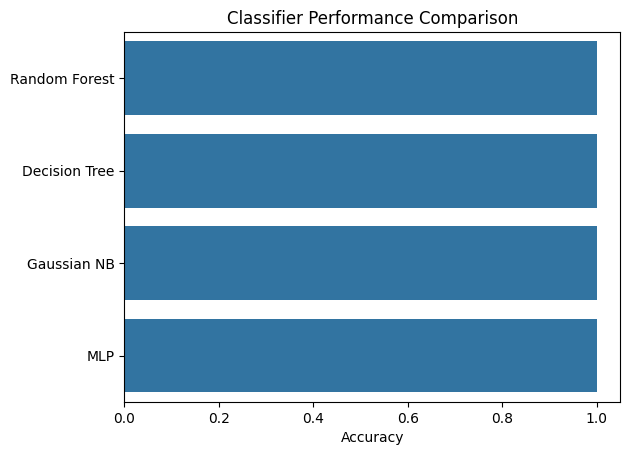

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

def evaluate_classifiers(X_train, y_train, X_test, y_test):
    classifiers = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Gaussian NB': GaussianNB(),
        'MLP': MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
    }
    
    results = []
    
    for name, clf in classifiers.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results.append((name, acc))
        print(f"{name} Accuracy: {acc:.4f}")
        print(classification_report(y_test, y_pred))
    
    return results

results = evaluate_classifiers(Xc_train, yc_train, Xc_test, yc_test)

names, scores = zip(*results)
sns.barplot(x=scores, y=names)
plt.xlabel("Accuracy")
plt.title("Classifier Performance Comparison")
plt.show()

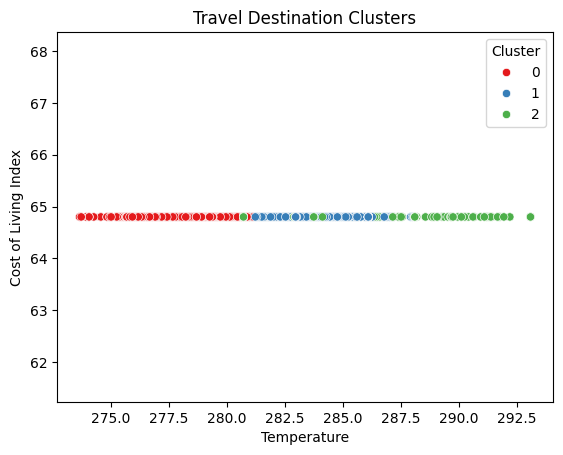

In [9]:
sns.scatterplot(data=cluster_data, x='temperature', y='Cost of Living Index', hue='Cluster', palette='Set1')
plt.title('Travel Destination Clusters')
plt.xlabel('Temperature')
plt.ylabel('Cost of Living Index')
plt.show()

In [10]:
# Predict Trip Cost
input_trip = pd.DataFrame({'Duration (days)': [2], 'Traveler age': [19]})
predicted_cost = model.predict(input_trip)
print("\nPredicted Trip Cost for 10 days & age 30:", predicted_cost[0])


Predicted Trip Cost for 10 days & age 30: 19178.599621702167


In [11]:
# Predict Disease Cases
input_health = pd.DataFrame({'Temp': [27.0], 'preci': [120.0], 'LAI': [2.5]})
predicted_cases = health_model.predict(input_health)
print("Predicted Disease Cases for given weather conditions:", predicted_cases[0])

Predicted Disease Cases for given weather conditions: 6418.1850113367545


In [12]:
# Check Travel Suitability
input_suitability = pd.DataFrame({'Duration (days)': [7], 'Traveler age': [22]})
is_suitable = clf.predict(input_suitability)
print("Is the trip suitable?", "Yes" if is_suitable[0] == 1 else "No")

Is the trip suitable? No


In [13]:
# Predict Destination Cluster
input_cluster = pd.DataFrame({'temperature': [39], 'humidity': [91], 'Cost of Living Index': [46]})
input_cluster_scaled = scaler.transform(input_cluster)
predicted_cluster = kmeans.predict(input_cluster_scaled)
print("Predicted Destination Cluster:", predicted_cluster[0])

Predicted Destination Cluster: 0


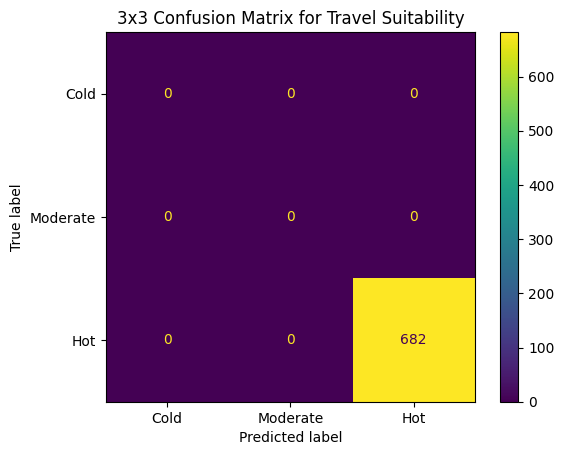

In [30]:
def classify_temp(temp):
    if temp < 15:
        return 0  # Cold
    elif 15 <= temp <= 30:
        return 1  # Moderate (Ideal)
    else:
        return 2  # Hot

trip_merged['Safe_Level'] = trip_merged['temperature'].apply(classify_temp)
clf_data = trip_merged.dropna(subset=features + ['Safe_Level'])
Xc = clf_data[features]
yc = clf_data['Safe_Level']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42)
clf = RandomForestClassifier(random_state=42)
clf.fit(Xc_train, yc_train)
yc_pred = clf.predict(Xc_test)

# 3x3 confusion matrix
cm = confusion_matrix(yc_test, yc_pred, labels=[0, 1, 2])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Cold", "Moderate", "Hot"]).plot()
plt.title("3x3 Confusion Matrix for Travel Suitability")
plt.show()


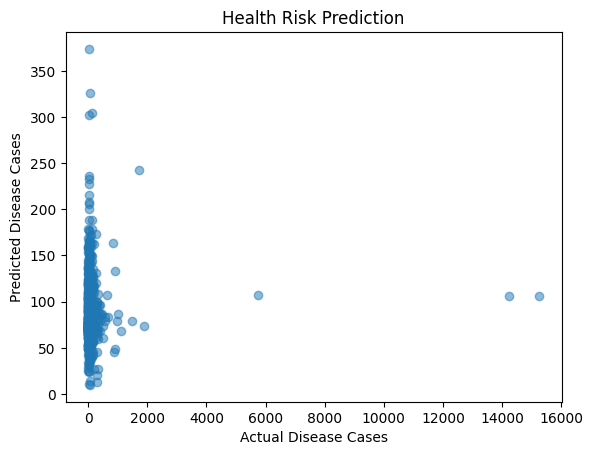

In [21]:
plt.scatter(yh_test, yh_pred, alpha=0.5)
plt.xlabel("Actual Disease Cases")
plt.ylabel("Predicted Disease Cases")
plt.title("Health Risk Prediction")
plt.show()

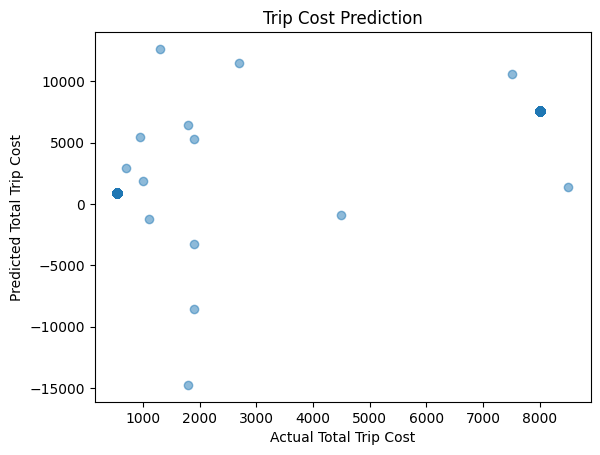

In [22]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Total Trip Cost")
plt.ylabel("Predicted Total Trip Cost")
plt.title("Trip Cost Prediction")
plt.show()